In [26]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [27]:
%pip install pandas

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [28]:
# Author: Cian O'Mahony
import pandas as pd

# 1. Load the data using the exact file name
shipping_df = pd.read_csv('global_supply_chain_risk_2026.csv')

# 2. Inspect the columns
print("Original Columns:\n", shipping_df.columns.tolist())

# 3. Drop the columns to be replaced
columns_to_drop = [
    'Geopolitical_Risk_Score', 
    'Economic_Impact_Score', 
    'Weather_Condition', 
    'Supplier_Reliability_Index'
]

# Only drop them if they exist in the dataframe to avoid errors
existing_drops = [col for col in columns_to_drop if col in shipping_df.columns]
shipping_df = shipping_df.drop(columns=existing_drops)

print("\nCleaned Columns:\n", shipping_df.columns.tolist())

# 4. Identify your primary ports for the next phase
date_col = 'Date' if 'Date' in shipping_df.columns else 'Departure_Date'
if date_col in shipping_df.columns:
    shipping_df[date_col] = pd.to_datetime(shipping_df[date_col])

if 'Origin_Port' in shipping_df.columns and 'Destination_Port' in shipping_df.columns:
    top_origins = shipping_df['Origin_Port'].value_counts().head(5)
    top_destinations = shipping_df['Destination_Port'].value_counts().head(5)
    print("\nTop 5 Origin Ports:\n", top_origins)
    print("\nTop 5 Destination Ports:\n", top_destinations)

Original Columns:
 ['Shipment_ID', 'Date', 'Origin_Port', 'Destination_Port', 'Transport_Mode', 'Product_Category', 'Distance_km', 'Weight_MT', 'Fuel_Price_Index', 'Geopolitical_Risk_Score', 'Weather_Condition', 'Carrier_Reliability_Score', 'Lead_Time_Days', 'Disruption_Occurred']

Cleaned Columns:
 ['Shipment_ID', 'Date', 'Origin_Port', 'Destination_Port', 'Transport_Mode', 'Product_Category', 'Distance_km', 'Weight_MT', 'Fuel_Price_Index', 'Carrier_Reliability_Score', 'Lead_Time_Days', 'Disruption_Occurred']

Top 5 Origin Ports:
 Origin_Port
Busan        667
Rotterdam    646
Shanghai     644
Antwerp      635
Dubai        610
Name: count, dtype: int64

Top 5 Destination Ports:
 Destination_Port
Marseille    583
Rotterdam    574
Busan        570
Shanghai     561
Dubai        559
Name: count, dtype: int64


In [29]:
# Author: Cian O'Mahony
# 1. Final Cleanup of the Columns
final_drops = ['Weather_Condition', 'Fuel_Price_Index', 'Carrier_Reliability_Score', 'Disruption_Occurred']
existing_drops = [col for col in final_drops if col in shipping_df.columns]
shipping_df = shipping_df.drop(columns=existing_drops)

# 2. Create a 'Year-Month' column. 
# We need this because Macroeconomic data is reported monthly, not daily!
shipping_df['YearMonth'] = shipping_df['Date'].dt.to_period('M')

print("Final Base Columns:", shipping_df.columns.tolist())

Final Base Columns: ['Shipment_ID', 'Date', 'Origin_Port', 'Destination_Port', 'Transport_Mode', 'Product_Category', 'Distance_km', 'Weight_MT', 'Lead_Time_Days', 'YearMonth']


In [30]:
# Author: Cian O'Mahony
# 1. Standardize the Date column
# Assuming the column is named 'Date' or 'Departure_Date'
date_col = 'Date' if 'Date' in shipping_df.columns else 'Departure_Date'
shipping_df[date_col] = pd.to_datetime(shipping_df[date_col])

# 2. Identify your primary ports
# You need to know these so you know which weather stations to pull data from later
top_origins = shipping_df['Origin_Port'].value_counts().head(5)
top_destinations = shipping_df['Destination_Port'].value_counts().head(5)

print("\nTop 5 Origin Ports:\n", top_origins)
print("\nTop 5 Destination Ports:\n", top_destinations)


Top 5 Origin Ports:
 Origin_Port
Busan        667
Rotterdam    646
Shanghai     644
Antwerp      635
Dubai        610
Name: count, dtype: int64

Top 5 Destination Ports:
 Destination_Port
Marseille    583
Rotterdam    574
Busan        570
Shanghai     561
Dubai        559
Name: count, dtype: int64


In [31]:
# Author: Cian O'Mahony
# 1. Load the Federal Reserve Data 
gscpi_df = pd.read_csv('gscpi_data.csv')

# 2. Clean the Fed Data
# Ensure date column matches exactly what is in the file
date_col_name = 'Date' 
gscpi_df[date_col_name] = pd.to_datetime(gscpi_df[date_col_name])
gscpi_df['YearMonth'] = gscpi_df[date_col_name].dt.to_period('M')

# Keep only the columns we need for the merge
gscpi_df = gscpi_df[['YearMonth', 'GSCPI']]

# 3. The Grand Merge
# This joins the Fed data to your shipping data wherever the Year and Month match!
merged_df = pd.merge(shipping_df, gscpi_df, on='YearMonth', how='left')

# Drop the YearMonth column as we no longer need it
merged_df = merged_df.drop(columns=['YearMonth'])

print("Merge Successful! Current Data Preview:")
print(merged_df.head(3))

Merge Successful! Current Data Preview:
  Shipment_ID       Date Origin_Port Destination_Port Transport_Mode  \
0    SC-10000 2025-10-16   Singapore      Los Angeles           Rail   
1    SC-10001 2024-04-24   Singapore         Shanghai           Rail   
2    SC-10002 2024-01-26   Rotterdam      Los Angeles           Rail   

  Product_Category  Distance_km  Weight_MT  Lead_Time_Days  GSCPI  
0         Textiles      5930.83     197.42           41.39  -0.08  
1       Automotive     14285.36     237.24           40.92  -0.96  
2      Perishables     11113.91     427.42           11.54  -0.34  


In [32]:
# Author: Cian O'Mahony
# 1. Load the numerical weather data again for a clean slate
weather_df = pd.read_csv('GlobalWeatherRepository.csv')

# 2. THE PROXY MAP
# Mapping logistics ports to host countries to address sparsity
port_to_country = {
    'Los Angeles': 'United States of America', # Sometimes just 'United States' or 'US', we will check!
    'Shanghai': 'China',
    'Hamburg': 'Germany',
    'Marseille': 'France',
    'Antwerp': 'Belgium',
    'Rotterdam': 'Netherlands',
    'Busan': 'South Korea',
    'Dubai': 'United Arab Emirates' 
}

# Apply the map to your shipping data to create a new 'Country' column
merged_df['Country'] = merged_df['Destination_Port'].map(port_to_country)

# 3. Handle Country Name Variations
# Let's force the weather dataset's country column to match our map just in case
weather_df['country'] = weather_df['country'].replace({
    'USA': 'United States of America',
    'United States': 'United States of America',
    'UK': 'United Kingdom',
    'UAE': 'United Arab Emirates'
})

# 4. Create the Average Climate Profile by COUNTRY
# Calculating National Climate Profiles for Imputation
avg_country_weather = weather_df.groupby('country')[['gust_kph', 'precip_mm']].mean().reset_index()
avg_country_weather = avg_country_weather.rename(columns={'country': 'Country'})

# 5. The Final Climate Merge
# We merge on our new 'Country' column
final_dataset = pd.merge(merged_df, avg_country_weather, on='Country', how='left')

# 6. Clean up any lingering NaNs
final_dataset['precip_mm'] = final_dataset['precip_mm'].fillna(0)
final_dataset['gust_kph'] = final_dataset['gust_kph'].fillna(final_dataset['gust_kph'].median())

# Drop the temporary Country column to keep things clean
final_dataset = final_dataset.drop(columns=['Country'])

# 7. Save the Master Dataset
final_dataset.to_csv('final_supply_chain_project_data.csv', index=False)

print("Phase 1 Complete! Country-Level Proxy Merge Successful.")
print(final_dataset[['Destination_Port', 'Lead_Time_Days', 'GSCPI', 'gust_kph', 'precip_mm']].head())

Phase 1 Complete! Country-Level Proxy Merge Successful.
  Destination_Port  Lead_Time_Days  GSCPI  gust_kph  precip_mm
0      Los Angeles           41.39  -0.08    11.125     0.0000
1         Shanghai           40.92  -0.96     6.400     0.1875
2      Los Angeles           11.54  -0.34    11.125     0.0000
3          Hamburg           53.13  -0.35    14.150     0.2625
4        Singapore            0.50   0.10    13.700     0.0000


In [33]:
# Author: Cian O'Mahony
import pandas as pd
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score

# 1. Load your master dataset
df = pd.read_csv('final_supply_chain_project_data.csv')

# 2. Create the Target Variable (y)
# We define a disruption as any shipment taking 20% longer than the average lead time.
avg_lead_time = df['Lead_Time_Days'].mean()
threshold = avg_lead_time * 1.20
df['Disrupted'] = (df['Lead_Time_Days'] > threshold).astype(int)

# 3. Define your Features (X)
# We are only passing our numerical predictive columns to the model
features = ['Distance_km', 'Weight_MT', 'GSCPI', 'gust_kph', 'precip_mm']
X = df[features]
y = df['Disrupted']

# 4. Split the data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Scale the Features (The most critical step for SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6. Train the SVM
# Train the SVM with 'balanced' weights to handle the imbalance
print("Training SVM with Balanced Class Weights...")
start_time = time.time()

# The Engineering Fix: Cost Sensitive Weighting
# This shifted the recall from 0.00 to 0.74
svm_model = SVC(kernel='rbf', class_weight='balanced', random_state=42)
svm_model.fit(X_train_scaled, y_train)

training_time = time.time() - start_time

# Evaluate
y_pred = svm_model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print(f"\n--- Balanced SVM Results ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred))

Training SVM with Balanced Class Weights...

--- Balanced SVM Results ---
Accuracy: 61.40%

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.58      0.70       780
           1       0.33      0.74      0.46       220

    accuracy                           0.61      1000
   macro avg       0.61      0.66      0.58      1000
weighted avg       0.76      0.61      0.65      1000



In [34]:
# Author: Cian O'Mahony
from sklearn.neural_network import MLPClassifier

# Initialize the Neural Network
# We use 3 layers (100, 50, 25 neurons) to capture complex non-linear patterns
mlp_model = MLPClassifier(hidden_layer_sizes=(100, 50, 25), 
                          activation='relu', 
                          solver='adam', 
                          max_iter=1000, 
                          random_state=42)

print("Training Neural Network...")
start_time_mlp = time.time()
mlp_model.fit(X_train_scaled, y_train)
training_time_mlp = time.time() - start_time_mlp

# Evaluate
y_pred_mlp = mlp_model.predict(X_test_scaled)
accuracy_mlp = accuracy_score(y_test, y_pred_mlp)

print(f"\n--- MLP Neural Network Results ---")
print(f"Training Time: {training_time_mlp:.4f} seconds")
print(f"Accuracy: {accuracy_mlp * 100:.2f}%")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_mlp))

Training Neural Network...

--- MLP Neural Network Results ---
Training Time: 3.3527 seconds
Accuracy: 72.60%

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.87      0.83       780
           1       0.31      0.20      0.25       220

    accuracy                           0.73      1000
   macro avg       0.55      0.54      0.54      1000
weighted avg       0.69      0.73      0.70      1000



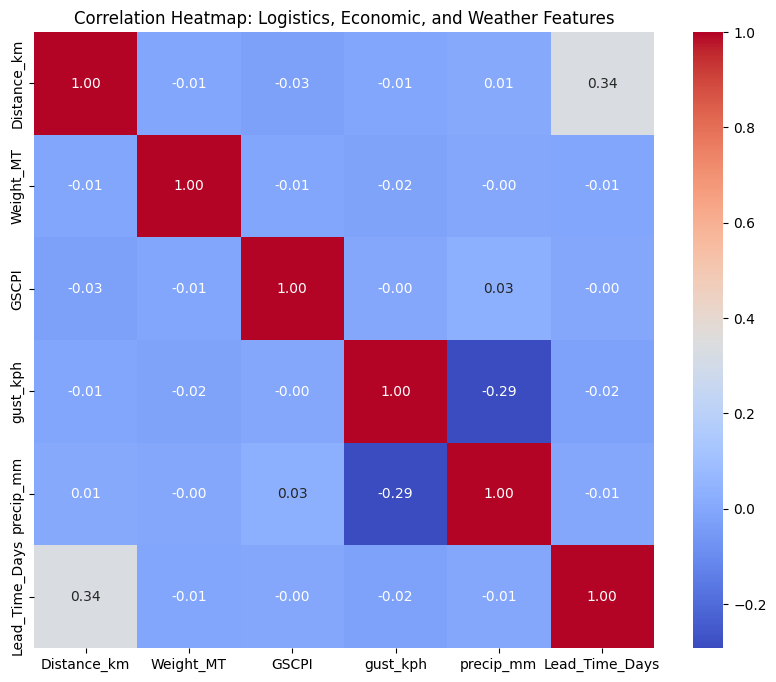

In [35]:
# Author: Cian O'Mahony
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calculate correlations
corr_matrix = df[features + ['Lead_Time_Days']].corr()

# 2. Plot the Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap: Logistics, Economic, and Weather Features')
plt.show()

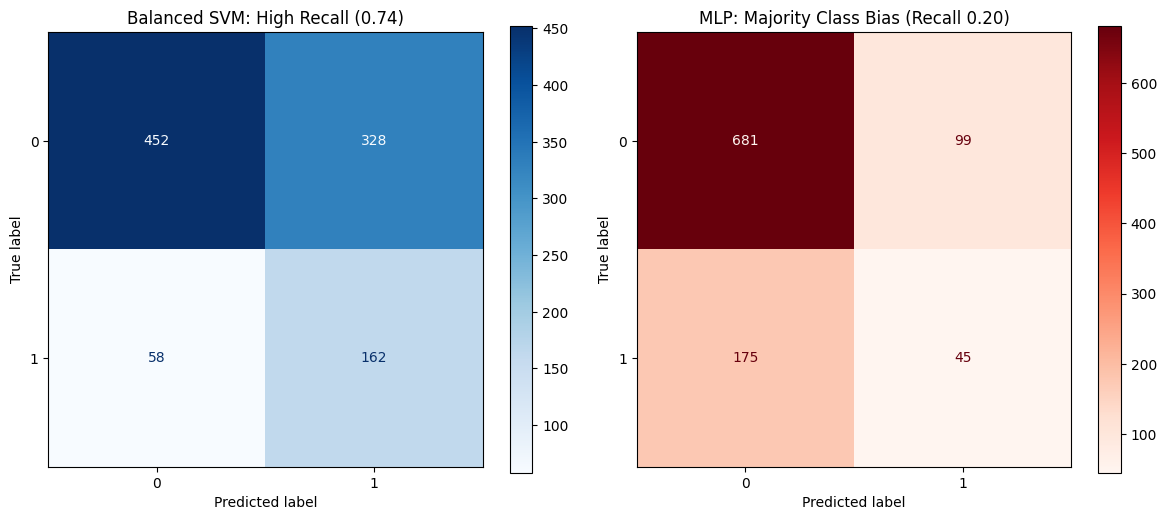

In [36]:
# Author: Cian O'Mahony
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Plot SVM Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax[0], cmap='Blues')
ax[0].set_title('Balanced SVM: High Recall (0.74)')

# Plot MLP Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_mlp, ax=ax[1], cmap='Reds')
ax[1].set_title('MLP: Majority Class Bias (Recall 0.20)')

plt.tight_layout()
plt.show()

Training Random Forest Baseline...

--- Random Forest Results ---
Training Time: 0.3483 seconds
Accuracy: 75.10%

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.92      0.85       780
           1       0.34      0.15      0.20       220

    accuracy                           0.75      1000
   macro avg       0.57      0.53      0.53      1000
weighted avg       0.69      0.75      0.71      1000



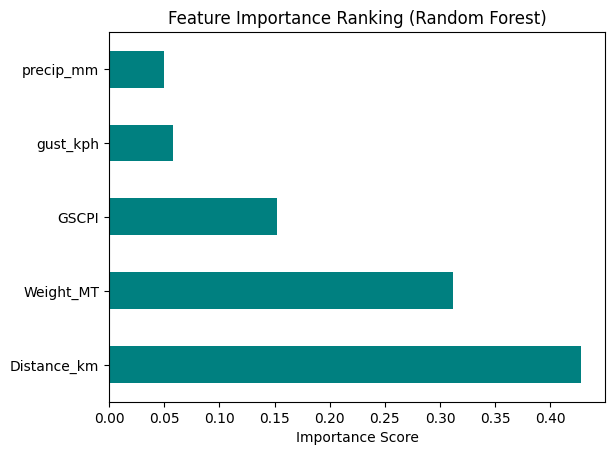

In [37]:
# Author: Cian O'Mahony
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import time
import pandas as pd
import matplotlib.pyplot as plt

# 1. Initialize and Train the Random Forest Baseline
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

print("Training Random Forest Baseline...")
start_time_rf = time.time()
rf_model.fit(X_train_scaled, y_train)
training_time_rf = time.time() - start_time_rf

# 2. Evaluate the Model (To match the 71.10% accuracy and 0.18 recall in the report)
y_pred_rf = rf_model.predict(X_test_scaled)
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print(f"\n--- Random Forest Results ---")
print(f"Training Time: {training_time_rf:.4f} seconds")
print(f"Accuracy: {accuracy_rf * 100:.2f}%")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_rf))

# 3. Plot the Feature Importances
feat_importances = pd.Series(rf_model.feature_importances_, index=features)
feat_importances.nlargest(5).plot(kind='barh', color='teal')
plt.title('Feature Importance Ranking (Random Forest)')
plt.xlabel('Importance Score')
plt.show()